In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render li, div.text_cell_render p{width:95% !important;font-size:20pt;padding:5px; line-height:30px;}
table.dataframe{font-size:22px;}
table td, th{font-size:16px;}
table{ margin-left:0 !important;   /* 왼쪽 여백 0 */}
</style>
"""))

<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
- 클러스터(cluster) : 독립변수의 특성이 유사한 데이터의 그룹
- 클러스터링(clustering) : 주어진 데이터를 여러 개의 클러스터로 구분하는 것
1) 중심 기반 클러스터링(K-Means)
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반 클러스터링(DBSCAN) 
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반 클러스터링(DBSCAN의 변형으로 OPTICS) 
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

# 2절. K-Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘의 하나
- 목적함수 값이 최소화될 때까지 클러스터의 중심(centroid) 𝜇k와 각 데이터가 소속될 클러스터를 반복해서 찾는 것
- K-Means 클러스터링의 세부 알고리즘
    1. 임의의 중심값 μk를 고릅니다.(보통 데이터 샘플 중의 하나를 선택합니다.)
    2. 중심에서 각 샘플 데이터까지의 거리를 계산합니다.
    3. 각 데이터 샘플에서 가장 가까운 중심을 선택하여 클러스터 갱신합니다.
    4. 다시 만들어진 클러스터에 대해 중심을 다시 계산하고 1~4를 반복합니다.

In [30]:
import matplotlib.pyplot as plt
# plt.rc('font', family='Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글깨짐 방지
plt.rcParams['axes.unicode_minus'] = False    # 축의 - 깨짐 방지
plt.rcParams['figure.figsize'] = (15,4) # 모든 시각화 사이즈

In [21]:
# 분류를 위한 가상 데이터 셋 생성
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=20, # 데이터 갯수(기본값100) : 20행
                          n_features=2,  # 독립변수 갯수(기본값20)
                          n_informative=2, # 독립변수 중 종속변수에 영향을 주는 독립변수 갯수(기본값2)
                          n_redundant=0,   # 종속변수에 영향을 안 미치는 독립변수 갯수(기본값2)
                          n_classes=2,     # 종속변수의 클래스 수(0, 1)
                          n_clusters_per_class=1, # 각 클래스 당 군의 갯수(서브그룹이 없음)
                          random_state=123)
X.shape, y.shape

((20, 2), (20,))

In [25]:
# 5:5로 분류되었는지 확인
import numpy as np
value, count = np.unique(y, return_counts=True)
{v:c for v, c in zip(value, count)}

{0: 10, 1: 10}

In [28]:
np.column_stack([X, y])[:3] # np.c_[X, y]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

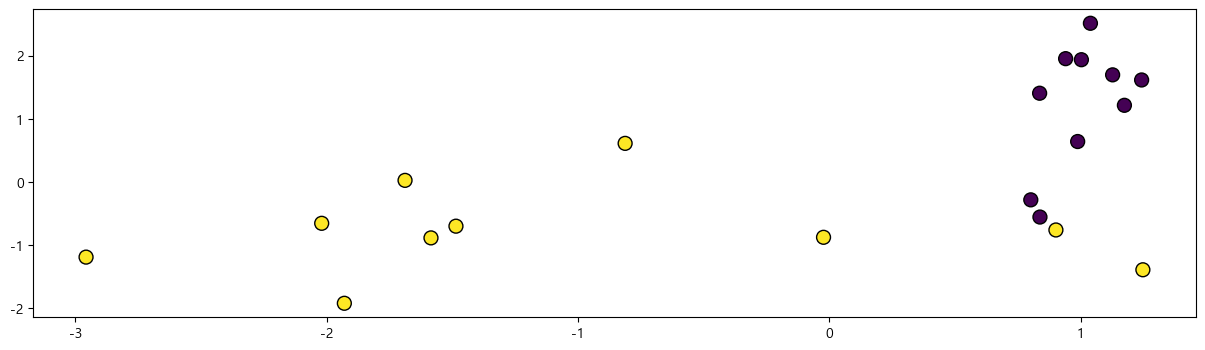

In [37]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='k')
plt.show()

In [61]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 갯수
              init='k-means++', # 초기중심점이 서로 멀리 떨어지도록 똑똑하게 초기화/'random'
              max_iter=300, # 각 실행에서 최대 300번 중심점 이동(중심점이 이동되지 않으면 300까지 안 해)
              n_init='auto'
              )
model.fit(X)

KMeans(n_clusters=2, n_init='auto')

In [62]:
c0, c1 = model.cluster_centers_ # 모델이 선정한 두 클러스터의 중심점
c0, c1

(array([-0.72607008, -0.71382205]), array([1.04359173, 1.62105848]))

In [63]:
print('실제값 :', y)
pred = model.predict(X)
print('예측값 :', pred)
labels = model.labels_
print('라 벨  :', labels)

실제값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
예측값 : [1 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1]
라 벨  : [1 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1]


In [64]:
# 0그룹으로 라벨링
X[labels==0]

array([[-1.6881048 ,  0.02599427],
       [ 0.90134424, -0.75896558],
       [-0.02317631, -0.87481215],
       [ 0.83780453, -0.554389  ],
       [-1.9295722 , -1.91894047],
       [-0.8124957 ,  0.61140818],
       [ 0.80138648, -0.28232585],
       [-1.48554751, -0.69890985],
       [ 1.24732102, -1.38872822],
       [-2.95714561, -1.18843377],
       [-1.5849172 , -0.88425569],
       [-2.0197379 , -0.65350646]])

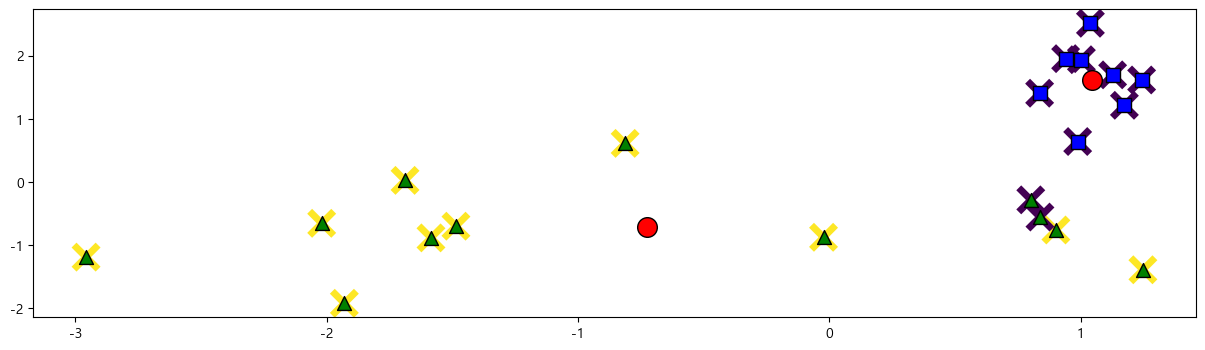

In [70]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=300, marker='x', linewidths=5)
plt.scatter(X[labels==0, 0], X[labels==0, 1], marker='^', c='g', edgecolors='k', s=100)
plt.scatter(X[labels==1, 0], X[labels==1, 1], marker='s', c='b', edgecolors='k', s=100)
plt.scatter(c0[0], c0[1], c='r', s=200, edgecolors='k')
plt.scatter(c1[0], c1[1], c='r', s=200, edgecolors='k')

In [74]:
# X데이터를 Normalizer를 이용한 변환
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
pd.concat([pd.DataFrame(X, columns=['x0', 'x1']),
          pd.DataFrame(Xnor, columns=['x0_nor', 'x1_nor'])],
          axis=1)

,x0,x1,x0_nor,x1_nor
0,1.038596,2.511754,0.382116,0.924114
1,1.002714,1.935215,0.460053,0.887892
2,-1.688105,0.025994,-0.999881,0.015397
3,0.901344,-0.758966,0.764937,-0.644105
4,0.836531,1.404882,0.511615,0.859215
5,-0.023176,-0.874812,-0.026484,-0.999649
6,0.837805,-0.554389,0.833951,-0.551839
7,-1.929572,-1.918940,-0.709057,-0.705151
8,-0.812496,0.611408,-0.799038,0.601281
9,1.126947,1.695701,0.553503,0.832847


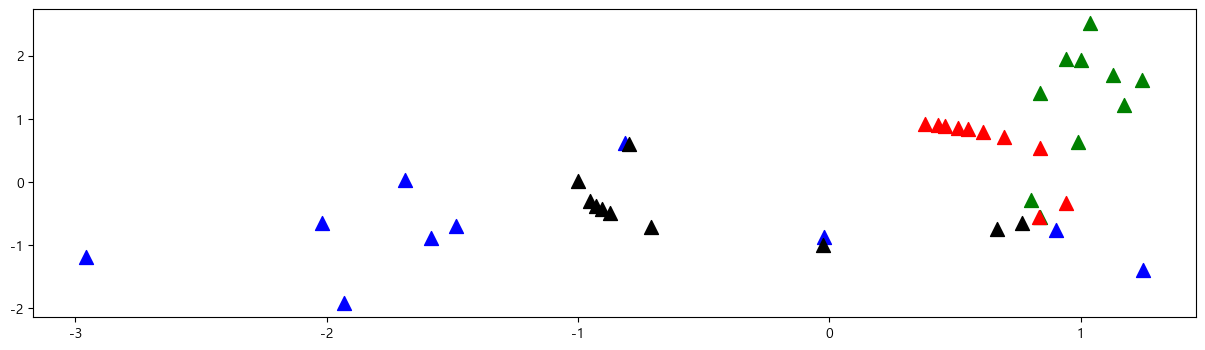

In [86]:
plt.scatter(X[y==0, 0], X[y==0, 1], s=100, marker='^', c='g')
plt.scatter(X[y==1, 0], X[y==1, 1], s=100, marker='^', c='b')

plt.scatter(Xnor[y==0, 0], Xnor[y==0, 1], s=100, marker='^', c='r')
plt.scatter(Xnor[y==1, 0], Xnor[y==1, 1], s=100, marker='^', c='k')

## K-means 클러스터링의 한계(pdf 13p)
- 군의 특성이 다를 경우
    * 크기(Sizes)
    * 밀도(Densities)
    * 비 구형(Non-globular shapes)
- 이상치를 포함할 경우 이상치를 없애고 클러스터링 진행

### 군의 크기가 다를 경우

In [97]:
# np.random.normal(평균, 표준편차, size)
# group0 : 평균 -10, 표준편차 2인 10행 2열 데이터
group0 = np.random.normal(-10, 2, (10, 2))
y0 = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y0]
group0[:3]

array([[-15.78817971, -10.79353061,   0.        ],
       [ -9.18684423,  -7.17536355,   0.        ],
       [-10.90589736, -11.01881273,   0.        ]])

In [91]:
# group1 : 평균 10, 표준편차 2인 10행 2열 데이터
group1 = np.random.normal(10, 2, (10, 2))
y1 = np.full(group0.shape[0], 1)
group1 = np.c_[group1, y1]
group1[:3]

array([[ 8.9688973 ,  5.17263057,  1.        ],
       [ 7.47972045, 10.7643018 ,  1.        ],
       [10.67789037, 11.90196855,  1.        ]])

In [93]:
# group2 : 평균0, 표준편차 5인 100행 2열 데이터
group2 = np.random.normal(0, 5, (100,2))
y2 = np.full(group2.shape[0], 2)
group2 = np.c_[group2, y2]
group2[:3]

array([[ 3.7525311 , -1.93579805,  2.        ],
       [ 3.24202544, 10.38720336,  2.        ],
       [ 0.81738097,  1.9156763 ,  2.        ]])

In [98]:
data = np.r_[group0, group1, group2] # 120행3열
data[::10]

array([[-15.78817971, -10.79353061,   0.        ],
       [  8.9688973 ,   5.17263057,   1.        ],
       [  3.7525311 ,  -1.93579805,   2.        ],
       [  2.92764286,   1.55218704,   2.        ],
       [ -5.75182547,  -8.25349212,   2.        ],
       [  8.86658702,  -0.85021564,   2.        ],
       [ -1.61428893,  -8.42398525,   2.        ],
       [  3.10151736,  -2.42450143,   2.        ],
       [  2.27753697,   5.732626  ,   2.        ],
       [  0.92649046,   6.50851439,   2.        ],
       [  1.7423104 ,   1.64282117,   2.        ],
       [ 11.38459628,   0.7999759 ,   2.        ]])

In [101]:
group0.shape, group1.shape, group2.shape, data.shape

((10, 3), (10, 3), (100, 3), (120, 3))

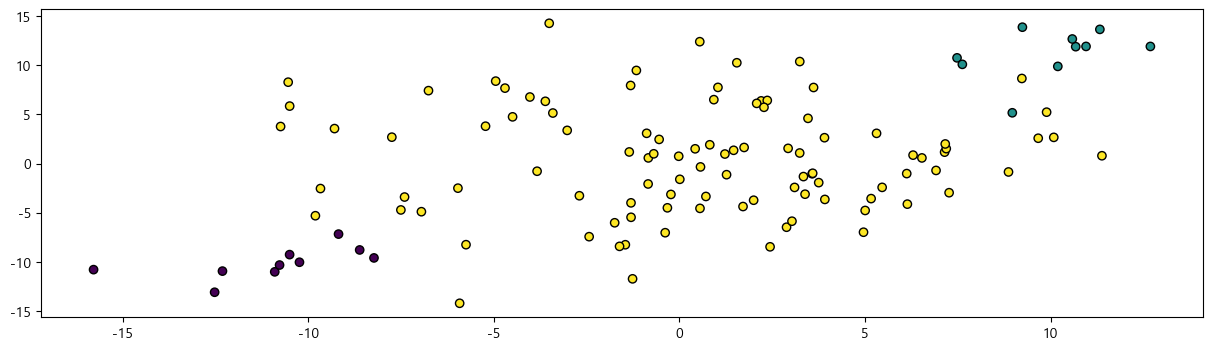

In [105]:
plt.scatter(data[:, 0],  data[:, 1], c=data[:, 2], edgecolors='k')
plt.show()

In [114]:
# 3개그룹으로 클러스터링
model = KMeans(n_clusters=3, n_init=5)
model.fit(data[:, :2])

KMeans(n_clusters=3, n_init=5)

In [115]:
labels = model.labels_ # 모델이 구분한 군들
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 0, 2, 1, 0, 0, 0, 1, 2, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 0, 0, 2, 0, 1,
       1, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 2, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 2, 1, 1, 1, 0, 0, 0, 0, 2, 0, 2, 1, 1, 1, 2,
       0, 2, 0, 0, 0, 1, 1, 2, 0, 0])

In [116]:
centers = model.cluster_centers_ # 군의 중심점

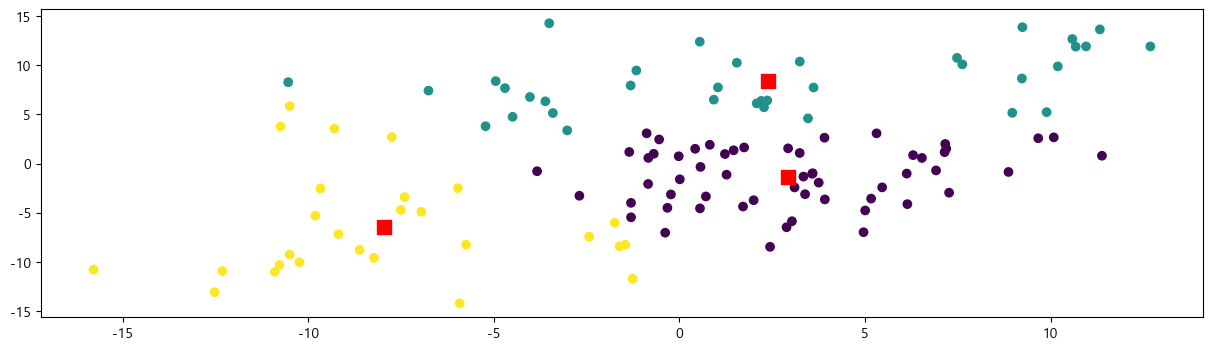

In [120]:
plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.scatter(centers[:,0], centers[:,1], c='r', s=100, marker='s')